In [1]:

#!/usr/bin/env python3
"""
Designing a convolutional linear data preconditioner for MNIST diffusion

Implements LP feasibility problem + bisection over gamma
optimizing over Fourier-domain weights s (for M^T M) and s_max, then constructs

    M = F^* diag(sqrt(s)) F

as a 784x784 *explicit* dense matrix (numpy array), with M acting on vec(X) where vec is
row-major flatten of a 28x28 image.

Notes:
  - The LaTeX discusses estimating class means from MNIST and a shared covariance Sigma0 = sigma0^2 I.
  - The diffusion schedule used to compute g(t) matches the provided DDPM code snippet via:
        alpha(t)^2  <->  alpha_bar[t]
        sigma_t^2   <->  1 - alpha_bar[t]
        g(t)        =    alpha_bar[t] / (1 - alpha_bar[t])
"""



'\nDesigning a convolutional linear data preconditioner for MNIST diffusion\n\nImplements LP feasibility problem + bisection over gamma\noptimizing over Fourier-domain weights s (for M^T M) and s_max, then constructs\n\n    M = F^* diag(sqrt(s)) F\n\nas a 784x784 *explicit* dense matrix (numpy array), with M acting on vec(X) where vec is\nrow-major flatten of a 28x28 image.\n\nNotes:\n  - The LaTeX discusses estimating class means from MNIST and a shared covariance Sigma0 = sigma0^2 I.\n  - The diffusion schedule used to compute g(t) matches the provided DDPM code snippet via:\n        alpha(t)^2  <->  alpha_bar[t]\n        sigma_t^2   <->  1 - alpha_bar[t]\n        g(t)        =    alpha_bar[t] / (1 - alpha_bar[t])\n'

In [2]:
import math
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import cvxpy as cp
from itertools import product
import matplotlib.pyplot as plt


In [3]:
# -----------------------------
# Dimensions
# -----------------------------
H = 28 
W = 28 
D = H * W  



In [4]:
# -----------------------------
# Vectorization (any fixed vec; we choose row-major)
# -----------------------------
def vec_img(x_hw: np.ndarray) -> np.ndarray:
    """vec: R^{H x W} -> R^D, row-major."""
    assert x_hw.shape == (H, W)
    return x_hw.reshape(-1)  # row-major


def unvec_img(x_d: np.ndarray) -> np.ndarray:
    """inverse vec: R^D -> R^{H x W}, row-major."""
    assert x_d.shape == (D,)
    return x_d.reshape(H, W)



In [5]:
# -----------------------------
# Diffusion schedule -> g(t)
# -----------------------------
def ddpm_g_from_linear_beta_schedule(
    T_steps: int = 400,               
    beta_start: float = 1e-4,         
    beta_end: float = 0.02,           
    clamp_eps: float = 1e-12,         
) -> np.ndarray:
    """
    Computes g(t) = alpha(t)^2 / sigma_t^2 using the discrete DDPM marginal:
        x_t = sqrt(alpha_bar[t]) x0 + sqrt(1 - alpha_bar[t]) eps
    so:
        alpha(t)^2  = alpha_bar[t]
        sigma_t^2   = 1 - alpha_bar[t]
        g(t)        = alpha_bar[t] / (1 - alpha_bar[t])
    """
    betas = torch.linspace(beta_start, beta_end, T_steps, device="cpu")  
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)  
    denom = torch.clamp(1.0 - alpha_bar, min=clamp_eps)
    g = (alpha_bar / denom).detach().cpu().numpy().astype(np.float64)    
    return g

In [6]:
# -----------------------------
# MNIST
# -----------------------------
def load_mnist_train():
    tfm = T.Compose([T.ToTensor()])  # gives [1,28,28] in [0,1]
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    return ds


# -----------------------------
# Means (mu_i) and sigma0 
# -----------------------------
def get_class_means(
    mnist_train,
    placeholder_seed: int = 0,            
    max_per_class: int = 5000,      
) -> np.ndarray:
    """
    Returns mu[i] as 28x28 arrays, shape [10, H, W].

    """
    

    sums = np.zeros((10, H, W), dtype=np.float64)
    counts = np.zeros((10,), dtype=np.int64)

    for x, y in mnist_train:
        yi = int(y)
        if counts[yi] >= max_per_class:
            if np.all(counts >= max_per_class):
                break
            continue
        x_hw = x[0].numpy().astype(np.float64)
        sums[yi] += x_hw
        counts[yi] += 1

    for i in range(10):
        if counts[i] == 0:
            raise RuntimeError(f"No samples collected for class {i}. Increase max_per_class.")
    mu = sums / counts[:, None, None]
    return mu

In [7]:
# -----------------------------
# D_close / D_far construction
# -----------------------------
def pairs_within(classes):
    cs = sorted(list(classes))
    out = []
    for a in range(len(cs)):
        for b in range(a + 1, len(cs)):
            out.append((cs[a], cs[b]))
    return out


def pairs_across(intra_classes, inter_classes):
    out = []
    for i in sorted(list(intra_classes)):
        for j in sorted(list(inter_classes)):
            if i == j:
                raise ValueError("intra_classes and inter_classes must be disjoint.")
            out.append((i, j))
    return out


def abs_dhat_sq_from_means(mu_hw: np.ndarray, pair_list):
    """
    For each (i,j) in pair_list, compute d = mu_i - mu_j (28x28),
    then d_hat = FFT2(d, norm='ortho'), and return |d_hat|^2 flattened (row-major).
    Returns A of shape [num_pairs, D], dtype float64.
    """
    A = []
    for (i, j) in pair_list:
        d_hw = (mu_hw[i] - mu_hw[j]).astype(np.float64)
        d_hat = np.fft.fft2(d_hw, norm="ortho")  # complex [H,W]
        A.append((np.abs(d_hat) ** 2).reshape(-1))  # flatten row-major
    if len(A) == 0:
        return np.zeros((0, D), dtype=np.float64)
    return np.stack(A, axis=0).astype(np.float64)


# -----------------------------
# Symmetry constraints
# -----------------------------
def symmetry_index_pairs(H_, W_):
    """
    Returns list of (idx, mirror_idx) with idx < mirror_idx, where:
        mirror(k,l) = ((H-k)%H, (W-l)%W)
    in row-major flattening idx = k*W + l.
    """
    pairs = []
    for k in range(H_):
        for l in range(W_):
            kk = (-k) % H_
            ll = (-l) % W_
            idx = k * W_ + l
            midx = kk * W_ + ll
            if idx < midx:
                pairs.append((idx, midx))
    return pairs



In [8]:
# -----------------------------
# LP builder
# -----------------------------
def build_lp_problem(
    A_close: np.ndarray,
    A_far: np.ndarray,
    g_grid: np.ndarray,
    delta_close: float,      
    sigma0: float,           
    eps_s: float,            
):
    
    assert A_close.shape[1] == D and A_far.shape[1] == D
    s = cp.Variable(D)          
    s_max = cp.Variable()       
    gamma_sq = cp.Parameter(nonneg=True)  

    constraints = []

    constraints += [s_max >= 0]
    constraints += [s >= eps_s]
    constraints += [s <= s_max]

    for idx, midx in symmetry_index_pairs(H, W):
        constraints += [s[idx] == s[midx]]
    
    if A_close.shape[0] > 0:
        for g in g_grid:
            constraints += [g * (A_close @ s) <= (delta_close ** 2) * np.ones(A_close.shape[0])]

   
    if A_far.shape[0] > 0:
        for g in g_grid:
            rhs = gamma_sq * (1.0 + (sigma0 ** 2) * g * s_max)  # scalar affine in s_max
            constraints += [g * (A_far @ s) >= rhs * np.ones(A_far.shape[0])]

    objective = cp.Minimize(s_max)

    problem = cp.Problem(objective, constraints)
    return problem, s, s_max, gamma_sq


# -----------------------------
# Bisection on gamma
# -----------------------------
def bisect_max_gamma(
    problem,
    s_var,
    smax_var,
    gamma_sq_param,
    gamma_hi_init: float = 1.0,
    gamma_hi_max: float = 1e3,
    bisection_iters: int = 25,
    solver: str = "ECOS",
    verbose_solver: bool = False,   # <-- set False to suppress solver spam
    print_progress: bool = True,    # <-- compact one-line logs
):
    """
    Monotone search (bracketing + bisection) for max feasible gamma.
    Returns: (gamma_star, s_star, smax_star, history)

    history is a dict with arrays you can plot:
      - attempted_gamma[k]
      - feasible[k] (bool)
      - best_feasible_gamma[k]
      - phase[k] in {"bracket","bisect"}
    """

    history = {
        "phase": [],
        "attempted_gamma": [],
        "feasible": [],
        "best_feasible_gamma": [],
        "status": [],
    }

    def log(phase, gamma, ok, best, status):
        history["phase"].append(phase)
        history["attempted_gamma"].append(float(gamma))
        history["feasible"].append(bool(ok))
        history["best_feasible_gamma"].append(float(best))
        history["status"].append(str(status))

    def solve_for_gamma(gamma):
        gamma_sq_param.value = float(gamma * gamma)
        try:
            problem.solve(solver=solver, verbose=verbose_solver)
        except Exception as e:
            # Treat solver error as infeasible, but record status clearly
            return False, None, None, f"error: {type(e).__name__}"

        status = problem.status
        ok = status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE)
        if ok:
            s_val = np.array(s_var.value).reshape(-1).astype(np.float64)
            smax_val = float(smax_var.value)
            return True, s_val, smax_val, status
        return False, None, None, status

    # --- Check gamma=0 feasibility (should be feasible; otherwise constraints too tight)
    ok0, s0, smax0, st0 = solve_for_gamma(0.0)
    log("bracket", 0.0, ok0, 0.0 if ok0 else 0.0, st0)
    if print_progress:
        print(f"[bracket] gamma=0.0 -> {'FEASIBLE' if ok0 else 'INFEASIBLE'} (status={st0})")

    if not ok0:
        raise RuntimeError(
            "LP infeasible even at gamma=0. "
            "This usually means your close constraints + eps_s are too strict."
        )

    gamma_lo = 0.0
    s_best, smax_best = s0, smax0

    # --- Bracket upper bound by doubling until infeasible
    gamma_hi = float(gamma_hi_init)
    while gamma_hi <= gamma_hi_max:
        ok, s_val, smax_val, st = solve_for_gamma(gamma_hi)
        if ok:
            gamma_lo = gamma_hi
            s_best, smax_best = s_val, smax_val
            log("bracket", gamma_hi, True, gamma_lo, st)
            if print_progress:
                print(f"[bracket] gamma={gamma_hi:.6g} -> FEASIBLE (best={gamma_lo:.6g})")
            gamma_hi *= 2.0
        else:
            log("bracket", gamma_hi, False, gamma_lo, st)
            if print_progress:
                print(f"[bracket] gamma={gamma_hi:.6g} -> INFEASIBLE (best={gamma_lo:.6g}, status={st})")
            break

    gamma_hi = min(gamma_hi, gamma_hi_max)

    # --- Bisection
    for it in range(bisection_iters):
        mid = 0.5 * (gamma_lo + gamma_hi)
        ok, s_val, smax_val, st = solve_for_gamma(mid)

        if ok:
            gamma_lo = mid
            s_best, smax_best = s_val, smax_val
            log("bisect", mid, True, gamma_lo, st)
            if print_progress:
                print(f"[bisect {it:02d}] gamma={mid:.6g} -> FEASIBLE (best={gamma_lo:.6g})")
        else:
            gamma_hi = mid
            log("bisect", mid, False, gamma_lo, st)
            if print_progress:
                print(f"[bisect {it:02d}] gamma={mid:.6g} -> INFEASIBLE (best={gamma_lo:.6g}, status={st})")

    return gamma_lo, s_best, smax_best, history



In [9]:
# -----------------------------
# Construct M 784x784 from s*
# -----------------------------
def apply_M_fft(x_hw: np.ndarray, sqrt_s_hw: np.ndarray) -> np.ndarray:
    """
    Y = M X via Fourier-domain rule:
      X_hat = DFT2(X), Y_hat = sqrt(s) * X_hat, Y = IDFT2(Y_hat)
    """
    X_hat = np.fft.fft2(x_hw, norm="ortho")
    Y_hat = sqrt_s_hw * X_hat
    y_hw = np.fft.ifft2(Y_hat, norm="ortho")
    y_hw = np.real_if_close(y_hw, tol=1e3)  # should be real if symmetry satisfied
    return np.asarray(y_hw, dtype=np.float64)


def build_dense_M_from_s(s_hw: np.ndarray) -> np.ndarray:
    assert s_hw.shape == (H, W)
    sqrt_s_hw = np.sqrt(s_hw)

    M = np.zeros((D, D), dtype=np.float64)
    for p in range(D):
        e = np.zeros((D,), dtype=np.float64)
        e[p] = 1.0
        e_hw = unvec_img(e)
        y_hw = apply_M_fft(e_hw, sqrt_s_hw)
        M[:, p] = vec_img(y_hw)
    return M


def build_dense_Minv_from_s(s_hw: np.ndarray) -> np.ndarray:
    

    assert np.all(s_hw > 0), "Need s[ω] > 0 to build M^{-1}."
    inv_sqrt_s_hw = 1.0 / np.sqrt(s_hw)

    Minv = np.zeros((D, D), dtype=np.float64)
    for p in range(D):
        e = np.zeros((D,), dtype=np.float64)
        e[p] = 1.0
        e_hw = unvec_img(e)
        # apply inverse in Fourier domain
        E_hat = np.fft.fft2(e_hw, norm="ortho")
        X_hat = inv_sqrt_s_hw * E_hat
        x_hw = np.fft.ifft2(X_hat, norm="ortho")
        x_hw = np.real_if_close(x_hw, tol=1e3)
        Minv[:, p] = vec_img(np.asarray(x_hw, dtype=np.float64))
    return Minv



In [10]:

def plot_gamma_bisection_history(history, title="Bisection progress (gamma)"):
    """
    Plots:
      - attempted gamma each iteration (feasible vs infeasible markers)
      - best feasible gamma so far (step-like curve)

    Handles infeasible iterations by plotting them with red X markers.
    """
    gam = np.array(history["attempted_gamma"], dtype=float)
    feas = np.array(history["feasible"], dtype=bool)
    best = np.array(history["best_feasible_gamma"], dtype=float)
    phase = np.array(history["phase"])

    x = np.arange(len(gam))

    plt.figure(figsize=(9, 4))
    plt.title(title)

    # attempted gammas (feasible / infeasible)
    plt.scatter(x[feas], gam[feas], marker="o", label="attempted gamma (feasible)")
    plt.scatter(x[~feas], gam[~feas], marker="x", label="attempted gamma (infeasible)")

    # best feasible so far
    plt.plot(x, best, linewidth=2, label="best feasible gamma so far")

    # optionally show which points were bracket vs bisect (faint vertical separators)
    # Comment out if you want even less clutter.
    for i in np.where(phase == "bisect")[0][:1]:
        plt.axvline(i - 0.5, alpha=0.2)

    plt.xlabel("solve call index (bracket + bisect)")
    plt.ylabel("gamma")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# -----------------------------
# design
# -----------------------------
def design_mnist_preconditioner(
    intra_classes,                      
    inter_classes,                      
    time_grid=None,                     
    delta_close: float = 0.5,           
    sigma0: float = 3.121,              
    eps_s: float = 1e-8,                
    T_steps: int = 400,                 
    beta_start: float = 1e-4,           
    beta_end: float = 0.02,             
    # Means 
    placeholder_seed: int = 0,          
    max_per_class: int = 5000,          
    # Bisection 
    gamma_hi_init: float = 1.0,         
    gamma_hi_max: float = 200.0,        
    bisection_iters: int = 20,          
    # CVXPY
    solver: str = "ECOS",               
    verbose: bool = False,
):
    intra_classes = set(intra_classes)
    inter_classes = set(inter_classes)
    if len(intra_classes & inter_classes) > 0:
        raise ValueError("intra_classes and inter_classes must be disjoint.")
    for c in list(intra_classes | inter_classes):
        if c not in set(range(10)):
            raise ValueError("Classes must be in {0,...,9}.")

    if time_grid is None:
        time_grid = [50,51,52]

    g_all = ddpm_g_from_linear_beta_schedule(T_steps=T_steps, beta_start=beta_start, beta_end=beta_end)
    time_grid = [int(t) for t in time_grid if 0 <= int(t) < T_steps]
    if len(time_grid) == 0:
        raise ValueError("time_grid must contain at least one valid index in [0, T_steps-1].")
    g_grid = g_all[time_grid].astype(np.float64)

    mnist_train = load_mnist_train()
    mu_hw = get_class_means(
        mnist_train,
        placeholder_seed=placeholder_seed,
        max_per_class=max_per_class,
    )  

    close_pairs = pairs_within(intra_classes)  
    far_pairs = pairs_across(intra_classes, inter_classes)  

    A_close = abs_dhat_sq_from_means(mu_hw, close_pairs)  
    A_far = abs_dhat_sq_from_means(mu_hw, far_pairs)      

    problem, s_var, smax_var, gamma_sq_param = build_lp_problem(
        A_close=A_close,
        A_far=A_far,
        g_grid=g_grid,
        delta_close=delta_close,
        sigma0=sigma0,
        eps_s=eps_s,
    )
    

    gamma_star, s_star, smax_star, hist = bisect_max_gamma(
    problem=problem,
    s_var=s_var,
    smax_var=smax_var,
    gamma_sq_param=gamma_sq_param,
    gamma_hi_init=gamma_hi_init,
    gamma_hi_max=gamma_hi_max,
    bisection_iters=bisection_iters,
    solver=solver,
    verbose_solver=False,   # suppress CVXPY/SCS/ECOS iteration spam
    print_progress=True)    # one-line per attempt: FEASIBLE/INFEASIBLE + gamma

    
    s_hw = s_star.reshape(H, W)

    M = build_dense_M_from_s(s_hw)

    return {
    "gamma_star": float(gamma_star),
    "s_star": s_star,
    "s_max_star": float(smax_star),
    "M": M,
    "time_grid": time_grid,
    "g_grid": g_grid,
    "mu_hw": mu_hw,
    "bisect_history": hist} 




In [12]:
# ------------------------------------------------------------
# View the *spatial convolution mask/kernel* corresponding to s[ω]
# (consistent with the same row/column stacking used when building M)
#
# Recall: M = F^* diag(sqrt(s)) F
# So sqrt(s)[k,l] is the frequency response, and the spatial kernel m[u,v]
# is the inverse 2D DFT of sqrt(s).
# ------------------------------------------------------------

def s_to_kernel_hw(s_flat: np.ndarray, clip_negative: bool = True) -> np.ndarray:
    """
    Convert s[ω] (flattened row-major over (k,l)) into the spatial kernel m[u,v].

    This matches the convention used in the earlier construction:
      - images are treated as (H,W) arrays
      - vec() is row-major flatten
      - frequency grid ω=(k,l) is stored row-major (k major, l minor)
      - FFT/IFFT use norm='ortho'
    """
    assert s_flat.shape == (H * W,), f"expected shape {(H*W,)}, got {s_flat.shape}"
    s_hw = s_flat.reshape(H, W).astype(np.float64)  # row-major -> (k,l) grid

    if clip_negative:
        # If your LP solver produced tiny negatives (e.g. -1e-6), clip for sqrt.
        s_hw = np.maximum(s_hw, 0.0)

    sqrt_s_hw = np.sqrt(s_hw)

    # Spatial kernel (circular convolution mask):
    # m = IDFT2( sqrt(s) )
    m_hw = np.fft.ifft2(sqrt_s_hw, norm="ortho")
    m_hw = np.real_if_close(m_hw, tol=1e3)  # should be real if symmetry constraints held
    return np.asarray(m_hw, dtype=np.float64)

def show_kernel_heatmap(s_flat: np.ndarray, center: bool = True, title: str = "Spatial convolution mask m[u,v]"):
    """
    Visualize the spatial kernel as a heatmap.
    - center=True uses fftshift so the (0,0) impulse position appears centered for readability.
      (Computation uses the unshifted kernel; shifting is only for display.)
    """

    #view in log(abs()) since it's hard to tell what's 0 or just very close since machine percision
    
    m_hw = np.log(np.abs(s_to_kernel_hw(s_flat)))

    m_vis = np.fft.fftshift(m_hw) if center else m_hw

    plt.figure(figsize=(5, 4))
    plt.title(title + (" ()" if center else ""))
    plt.imshow(m_vis, aspect="equal")
    plt.colorbar()
    plt.axis("off")
    plt.show()

    return m_hw  # return the kernel used by circular convolution


In [13]:

def apply_preconditioner_fft(x_hw: np.ndarray, s_flat: np.ndarray) -> np.ndarray:
    """
    Apply Y = M X where M = F^* diag(sqrt(s)) F (LaTeX),
    using 2D FFTs directly (no dense 784x784 needed).
    x_hw: (28,28) float
    s_flat: (784,) nonnegative real weights indexed by frequency (row-major k,l flatten)
    """
    s_hw = s_flat.reshape(28, 28).astype(np.float64)

    s_hw = np.maximum(s_hw, 0.0)
    sqrt_s = np.sqrt(s_hw)

    X_hat = np.fft.fft2(x_hw, norm="ortho")
    Y_hat = sqrt_s * X_hat
    y_hw = np.fft.ifft2(Y_hat, norm="ortho")
    y_hw = np.real_if_close(y_hw, tol=1e3)
    return np.asarray(y_hw, dtype=np.float64)

def show_before_after_pairs(
    out_dict,
    n_pairs: int = 12,
    seed: int = 0,
    normalize_each: bool = True,
    use_absolute: bool = True,
    title: str = "MNIST: original (left) vs preconditioned (right)",
):
    """
    Displays n_pairs random MNIST train images (original vs preconditioned).
    normalize_each: if True, scales each image to [0,1] for display separately.
    use_absolute: if True, displays abs(preconditioned) (sometimes helpful).
    """
    s_star = out_dict["s_star"]  # (784,)
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=torchvision.transforms.ToTensor())

    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n_pairs, replace=False)

    fig, axes = plt.subplots(n_pairs, 2, figsize=(5, 2.2 * n_pairs))
    if n_pairs == 1:
        axes = np.array([axes]) 

    fig.suptitle(title, y=0.995)

    for r, idx in enumerate(idxs):
        x_t, y = ds[int(idx)]
        x_hw = x_t[0].numpy().astype(np.float64)

        y_hw = apply_preconditioner_fft(x_hw, s_star)
        if use_absolute:
            y_hw = np.abs(y_hw)

        def disp(img):
            if not normalize_each:
                return img
            lo, hi = float(img.min()), float(img.max())
            if hi - lo < 1e-12:
                return np.zeros_like(img)
            return (img - lo) / (hi - lo)

        ax0, ax1 = axes[r, 0], axes[r, 1]
        ax0.imshow(disp(x_hw), cmap="gray")
        ax1.imshow(disp(y_hw), cmap="gray")

        ax0.set_title(f"orig (label={int(y)})")
        ax1.set_title("after M")

        ax0.axis("off")
        ax1.axis("off")

    plt.tight_layout()
    plt.show()

# show_before_after_pairs(out, n_pairs=10, seed=0, normalize_each=True)

In [14]:
def search_mnist_preconditioner_hyperparams(
    search_space: dict,
    top_k: int = 2,
    T_steps: int = 400,
    beta_end: float = 0.02,
    placeholder_seed: int = 0,
    max_per_class: int = 5000,
    gamma_hi_init: float = 1.0,
    gamma_hi_max: float = 200.0,
    solver: str = "ECOS",
    verbose_solver: bool = False,
    outer_print_progress: bool = True,
    inner_bisection_logs: bool = False,
    visualize_top_k: bool = True,
    center_kernel_display: bool = True,
    build_dense_M_for_top: bool = False,
):
    """
    Grid-search over:
      - intra_classes
      - inter_classes
      - time_grid
      - sigma0
      - eps_s
      - delta_close
      - beta_start
      - bisection_iters

    Parameters
    ----------
    search_space : dict
        Must contain the 8 keys above.

        Expected format:
          - search_space["intra_classes"] : list of class collections
                e.g. [{8}, {3}, {3,8}]
          - search_space["inter_classes"] : list of class collections
                e.g. [{1}, {0,1}]
          - search_space["time_grid"] : list of candidate time grids
                e.g. [[200], [50,51,52], [100,150,200]]
          - all others : list of scalar values

    Returns
    -------
    out : dict
        {
          "top_results": [...],   # length <= top_k, sorted best-first
          "all_results": [...],   # every attempted combo
          "mu_hw": mu_hw,         # cached class means used for all runs
        }

    Notes
    -----
    - This ranks kernels using the normalized mean circular distance of |kernel|
      away from (0,0). Higher = less impulse-like.
    - To keep the search practical, this does NOT build dense M for every combo.
      It only builds dense M for the top results if build_dense_M_for_top=True.
    """

    required_keys = [
        "intra_classes",
        "inter_classes",
        "time_grid",
        "sigma0",
        "eps_s",
        "delta_close",
        "beta_start",
        "bisection_iters",
    ]
    missing = [k for k in required_keys if k not in search_space]
    if missing:
        raise ValueError(f"search_space is missing keys: {missing}")

    # ---------
    # helpers
    # ---------
    def _as_class_set(x):
        if isinstance(x, (int, np.integer)):
            return {int(x)}
        return set(x)

    def _as_time_grid(x):
        if isinstance(x, (int, np.integer)):
            return [int(x)]
        return [int(t) for t in x]

    def _kernel_spread_score(kernel_hw: np.ndarray):
        """
        Score = normalized mean circular distance of |kernel| mass from (0,0).

        Also returns useful diagnostics:
          - origin_mass_frac
          - off_origin_mass_frac
        """
        mass = np.abs(np.asarray(kernel_hw, dtype=np.float64))
        total_mass = mass.sum()

        if (not np.isfinite(total_mass)) or total_mass <= 0:
            return -np.inf, {
                "origin_mass_frac": np.nan,
                "off_origin_mass_frac": np.nan,
                "mean_circular_distance": np.nan,
            }

        p = mass / total_mass

        # Circular distance on the 28x28 torus, since the operator is circular convolution
        du = np.minimum(np.arange(H), H - np.arange(H))
        dv = np.minimum(np.arange(W), W - np.arange(W))
        dist = np.sqrt(du[:, None] ** 2 + dv[None, :] ** 2)

        mean_dist = float((p * dist).sum())
        max_dist = float(dist.max()) + 1e-12
        score = mean_dist / max_dist

        diagnostics = {
            "origin_mass_frac": float(p[0, 0]),
            "off_origin_mass_frac": float(1.0 - p[0, 0]),
            "mean_circular_distance": float(score),
        }
        return float(score), diagnostics

    # ----------------------------------------------------
    # Cache MNIST + class means once for the whole search
    # ----------------------------------------------------
    mnist_train = load_mnist_train()
    mu_hw = get_class_means(
        mnist_train,
        placeholder_seed=placeholder_seed,
        max_per_class=max_per_class,
    )

    # ----------------------------------------------------
    # Grid product
    # ----------------------------------------------------
    grid_keys = required_keys
    grid_lists = [search_space[k] for k in grid_keys]
    total_combos = 1
    for vals in grid_lists:
        total_combos *= len(vals)

    all_results = []

    for combo_idx, combo_vals in enumerate(product(*grid_lists), start=1):
        raw_params = dict(zip(grid_keys, combo_vals))

        params = {
            "intra_classes": _as_class_set(raw_params["intra_classes"]),
            "inter_classes": _as_class_set(raw_params["inter_classes"]),
            "time_grid": _as_time_grid(raw_params["time_grid"]),
            "sigma0": float(raw_params["sigma0"]),
            "eps_s": float(raw_params["eps_s"]),
            "delta_close": float(raw_params["delta_close"]),
            "beta_start": float(raw_params["beta_start"]),
            "bisection_iters": int(raw_params["bisection_iters"]),
        }

        # keep a compact printable copy
        short_desc = (
            f"intra={sorted(params['intra_classes'])}, "
            f"inter={sorted(params['inter_classes'])}, "
            f"time_grid={params['time_grid']}, "
            f"sigma0={params['sigma0']}, "
            f"eps_s={params['eps_s']}, "
            f"delta_close={params['delta_close']}, "
            f"beta_start={params['beta_start']}, "
            f"bisection_iters={params['bisection_iters']}"
        )

        try:
            # basic validity
            if len(params["intra_classes"] & params["inter_classes"]) > 0:
                raise ValueError("intra_classes and inter_classes must be disjoint.")

            for c in params["intra_classes"] | params["inter_classes"]:
                if c not in set(range(10)):
                    raise ValueError("Classes must be in {0,...,9}.")

            # diffusion schedule -> selected g-grid
            g_all = ddpm_g_from_linear_beta_schedule(
                T_steps=T_steps,
                beta_start=params["beta_start"],
                beta_end=beta_end,
            )
            time_grid = [t for t in params["time_grid"] if 0 <= int(t) < T_steps]
            if len(time_grid) == 0:
                raise ValueError("time_grid must contain at least one valid index in [0, T_steps-1].")
            g_grid = g_all[time_grid].astype(np.float64)

            # class-pair construction
            close_pairs = pairs_within(params["intra_classes"])
            far_pairs = pairs_across(params["intra_classes"], params["inter_classes"])

            A_close = abs_dhat_sq_from_means(mu_hw, close_pairs)
            A_far = abs_dhat_sq_from_means(mu_hw, far_pairs)

            # LP + bisection
            problem, s_var, smax_var, gamma_sq_param = build_lp_problem(
                A_close=A_close,
                A_far=A_far,
                g_grid=g_grid,
                delta_close=params["delta_close"],
                sigma0=params["sigma0"],
                eps_s=params["eps_s"],
            )

            gamma_star, s_star, smax_star, hist = bisect_max_gamma(
                problem=problem,
                s_var=s_var,
                smax_var=smax_var,
                gamma_sq_param=gamma_sq_param,
                gamma_hi_init=gamma_hi_init,
                gamma_hi_max=gamma_hi_max,
                bisection_iters=params["bisection_iters"],
                solver=solver,
                verbose_solver=verbose_solver,
                print_progress=inner_bisection_logs,
            )

            # kernel + score
            kernel_hw = s_to_kernel_hw(s_star, clip_negative=True)
            score, score_details = _kernel_spread_score(kernel_hw)

            result = {
                "score": float(score),
                "score_details": score_details,
                "gamma_star": float(gamma_star),
                "s_max_star": float(smax_star),
                "s_star": np.asarray(s_star, dtype=np.float64).copy(),
                "kernel_hw": np.asarray(kernel_hw, dtype=np.float64).copy(),
                "time_grid": list(time_grid),
                "g_grid": np.asarray(g_grid, dtype=np.float64).copy(),
                "bisect_history": hist,
                "params": {
                    "intra_classes": set(params["intra_classes"]),
                    "inter_classes": set(params["inter_classes"]),
                    "time_grid": list(time_grid),
                    "sigma0": params["sigma0"],
                    "eps_s": params["eps_s"],
                    "delta_close": params["delta_close"],
                    "beta_start": params["beta_start"],
                    "bisection_iters": params["bisection_iters"],
                },
                "error": None,
            }

            all_results.append(result)

            if outer_print_progress:
                print(
                    f"[{combo_idx}/{total_combos}] "
                    f"score={score:.6f}, "
                    f"origin_mass={score_details['origin_mass_frac']:.6f}, "
                    f"gamma={gamma_star:.6f} | {short_desc}"
                )

        except Exception as e:
            result = {
                "score": -np.inf,
                "score_details": None,
                "gamma_star": None,
                "s_max_star": None,
                "s_star": None,
                "kernel_hw": None,
                "time_grid": params["time_grid"],
                "g_grid": None,
                "bisect_history": None,
                "params": {
                    "intra_classes": set(params["intra_classes"]),
                    "inter_classes": set(params["inter_classes"]),
                    "time_grid": list(params["time_grid"]),
                    "sigma0": params["sigma0"],
                    "eps_s": params["eps_s"],
                    "delta_close": params["delta_close"],
                    "beta_start": params["beta_start"],
                    "bisection_iters": params["bisection_iters"],
                },
                "error": repr(e),
            }
            all_results.append(result)

            if outer_print_progress:
                print(f"[{combo_idx}/{total_combos}] FAILED | {short_desc}")
                print(f"    error: {repr(e)}")

    # sort valid runs best-first
    valid_results = [r for r in all_results if np.isfinite(r["score"])]
    valid_results.sort(key=lambda r: r["score"], reverse=True)
    # top_results = valid_results[:top_k]
    top_results = valid_results[:top_k] + valid_results[-top_k:]

    # optionally build dense M only for the winners
    if build_dense_M_for_top:
        for r in top_results:
            s_hw = r["s_star"].reshape(H, W)
            r["M"] = build_dense_M_from_s(s_hw)

    # visualize top-k using your existing visualization utility
    if visualize_top_k:
        for rank, r in enumerate(top_results, start=1):
            p = r["params"]
            print("\n" + "=" * 80)
            print(f"Rank {rank}")
            print(f"score        : {r['score']:.6f}")
            print(f"origin_mass  : {r['score_details']['origin_mass_frac']:.6f}")
            print(f"gamma_star   : {r['gamma_star']:.6f}")
            print(f"s_max_star   : {r['s_max_star']:.6f}")
            print(f"params       : {p}")

            show_kernel_heatmap(
                r["s_star"],
                center=center_kernel_display,
                title=(
                    f"Rank {rank} | score={r['score']:.4f} | "
                    f"origin_mass={r['score_details']['origin_mass_frac']:.4f}"
                ),
            )

    return {
        "top_results": top_results,
        "all_results": all_results,
        "mu_hw": mu_hw,
    }


/tmp/ipykernel_2174930/1317802052.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(m_hw, dtype=np.float64)


[1/243] score=0.126616, origin_mass=0.765968, gamma=4.734375 | intra=[1], inter=[8], time_grid=[200], sigma0=1.0, eps_s=1e-05, delta_close=0.5, beta_start=1e-06, bisection_iters=10
[2/243] score=0.126616, origin_mass=0.765968, gamma=4.734375 | intra=[1], inter=[8], time_grid=[200], sigma0=1.0, eps_s=1e-05, delta_close=5.0, beta_start=1e-06, bisection_iters=10
[3/243] score=0.126616, origin_mass=0.765968, gamma=4.734375 | intra=[1], inter=[8], time_grid=[200], sigma0=1.0, eps_s=1e-05, delta_close=50.0, beta_start=1e-06, bisection_iters=10
[4/243] score=0.198361, origin_mass=0.600746, gamma=0.472656 | intra=[1], inter=[8], time_grid=[200], sigma0=10.0, eps_s=1e-05, delta_close=0.5, beta_start=1e-06, bisection_iters=10
[5/243] score=0.198361, origin_mass=0.600746, gamma=0.472656 | intra=[1], inter=[8], time_grid=[200], sigma0=10.0, eps_s=1e-05, delta_close=5.0, beta_start=1e-06, bisection_iters=10
[6/243] score=0.198361, origin_mass=0.600746, gamma=0.472656 | intra=[1], inter=[8], time_gr

/tmp/ipykernel_2174930/602324348.py:87: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver, verbose=verbose_solver)


[19/243] score=0.242249, origin_mass=0.505175, gamma=4.730469 | intra=[1], inter=[8], time_grid=[398], sigma0=1.0, eps_s=1e-05, delta_close=0.5, beta_start=1e-06, bisection_iters=10
[20/243] score=0.242249, origin_mass=0.505175, gamma=4.730469 | intra=[1], inter=[8], time_grid=[398], sigma0=1.0, eps_s=1e-05, delta_close=5.0, beta_start=1e-06, bisection_iters=10
[21/243] score=0.242249, origin_mass=0.505175, gamma=4.730469 | intra=[1], inter=[8], time_grid=[398], sigma0=1.0, eps_s=1e-05, delta_close=50.0, beta_start=1e-06, bisection_iters=10
[22/243] score=0.219289, origin_mass=0.558389, gamma=0.472656 | intra=[1], inter=[8], time_grid=[398], sigma0=10.0, eps_s=1e-05, delta_close=0.5, beta_start=1e-06, bisection_iters=10
[23/243] score=0.219289, origin_mass=0.558389, gamma=0.472656 | intra=[1], inter=[8], time_grid=[398], sigma0=10.0, eps_s=1e-05, delta_close=5.0, beta_start=1e-06, bisection_iters=10
[24/243] score=0.219289, origin_mass=0.558389, gamma=0.472656 | intra=[1], inter=[8], t

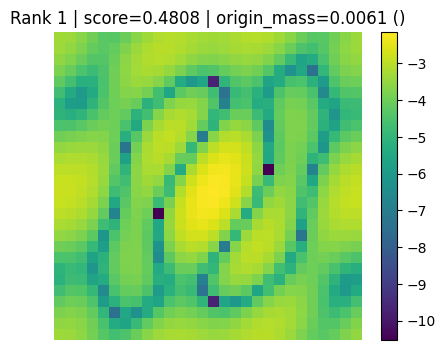


Rank 2
score        : 0.474955
origin_mass  : 0.005914
gamma_star   : 1.374023
s_max_star   : -0.009810
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [398], 'sigma0': 10.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


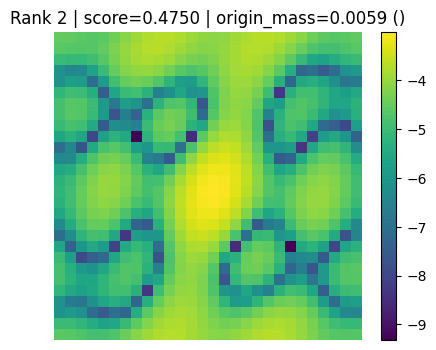


Rank 3
score        : 0.469799
origin_mass  : 0.033293
gamma_star   : 0.808594
s_max_star   : 56.259590
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}


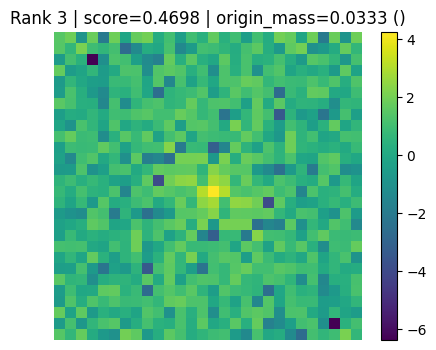


Rank 4
score        : 0.469661
origin_mass  : 0.080963
gamma_star   : 2.781250
s_max_star   : 82.893692
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


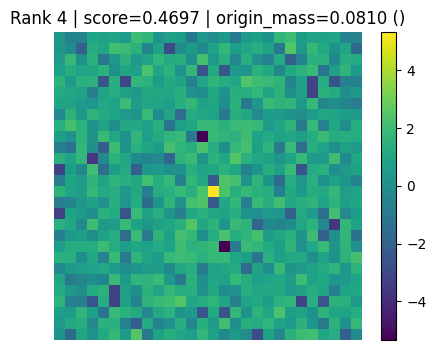


Rank 5
score        : 0.468237
origin_mass  : 0.034185
gamma_star   : 0.808594
s_max_star   : 9.097627
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [300], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}


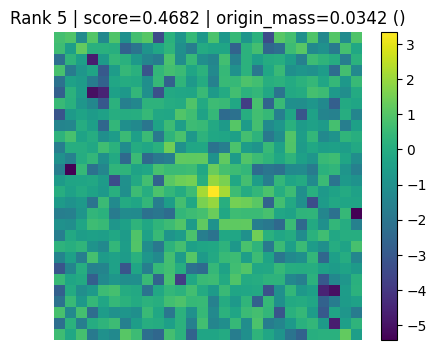


Rank 6
score        : 0.467705
origin_mass  : 0.034597
gamma_star   : 0.808594
s_max_star   : 1.826430
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}


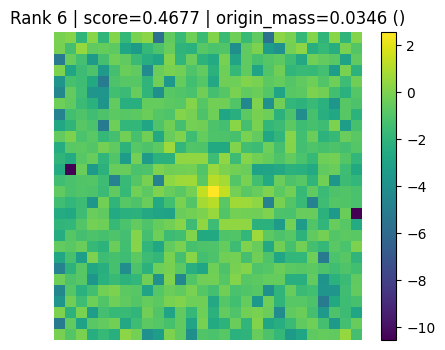


Rank 7
score        : 0.466367
origin_mass  : 0.108617
gamma_star   : 2.132812
s_max_star   : 77.350568
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {9}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


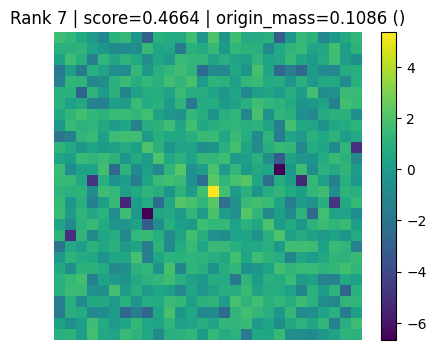


Rank 8
score        : 0.460202
origin_mass  : 0.005851
gamma_star   : 1.375977
s_max_star   : -0.011911
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {9}, 'time_grid': [398], 'sigma0': 10.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


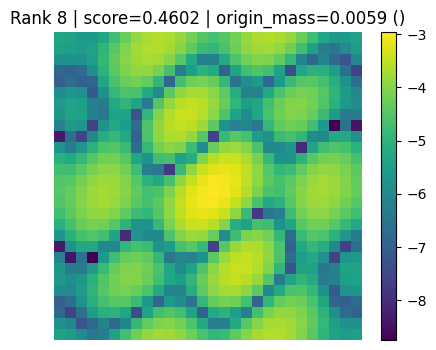


Rank 9
score        : 0.458072
origin_mass  : 0.036281
gamma_star   : 0.691406
s_max_star   : 9.766058
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8, 9, 0}, 'time_grid': [300], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}


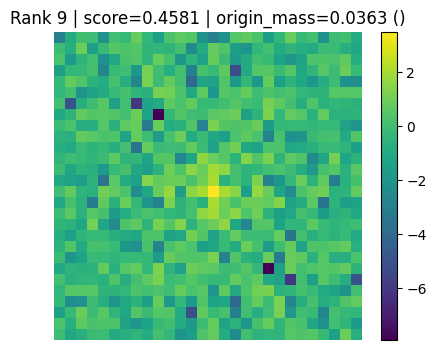


Rank 10
score        : 0.457563
origin_mass  : 0.108483
gamma_star   : 2.134766
s_max_star   : 12.441879
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8, 9, 0}, 'time_grid': [300], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


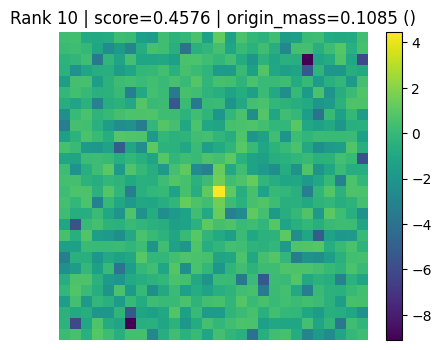


Rank 11
score        : 0.127255
origin_mass  : 0.764766
gamma_star   : 4.734375
s_max_star   : 21457.364068
params       : {'intra_classes': {1}, 'inter_classes': {8, 9, 0}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}


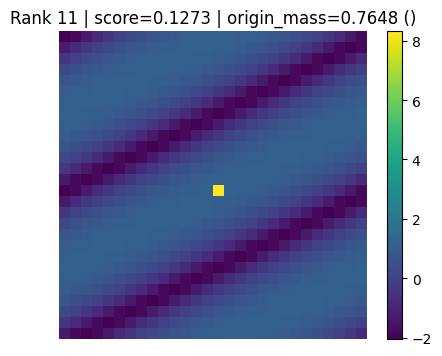


Rank 12
score        : 0.127255
origin_mass  : 0.764766
gamma_star   : 4.734375
s_max_star   : 21457.364068
params       : {'intra_classes': {1}, 'inter_classes': {8, 9, 0}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


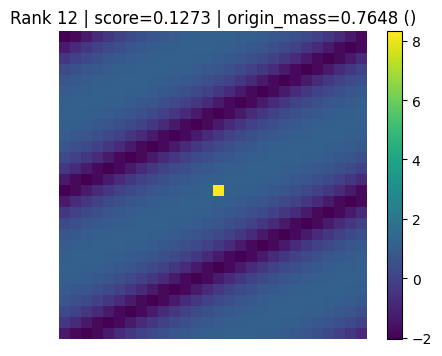


Rank 13
score        : 0.127255
origin_mass  : 0.764766
gamma_star   : 4.734375
s_max_star   : 21457.364068
params       : {'intra_classes': {1}, 'inter_classes': {8, 9, 0}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


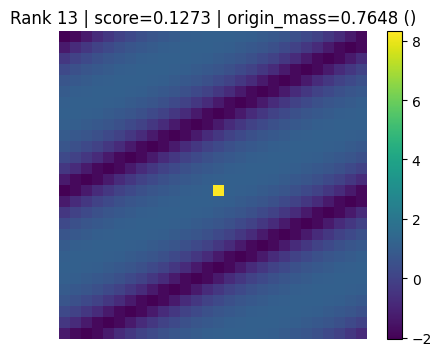


Rank 14
score        : 0.126616
origin_mass  : 0.765968
gamma_star   : 4.734375
s_max_star   : 21460.357856
params       : {'intra_classes': {1}, 'inter_classes': {8}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}


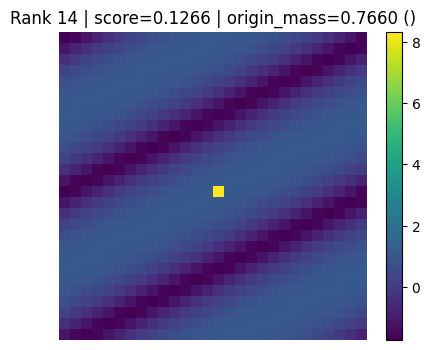


Rank 15
score        : 0.126616
origin_mass  : 0.765968
gamma_star   : 4.734375
s_max_star   : 21460.357856
params       : {'intra_classes': {1}, 'inter_classes': {8}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


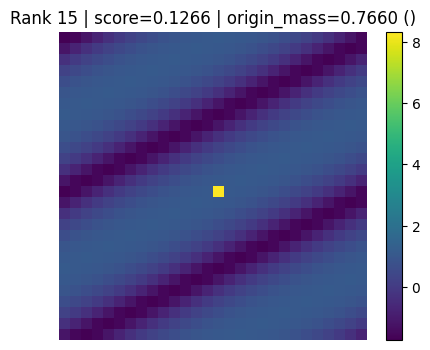


Rank 16
score        : 0.126616
origin_mass  : 0.765968
gamma_star   : 4.734375
s_max_star   : 21460.357856
params       : {'intra_classes': {1}, 'inter_classes': {8}, 'time_grid': [200], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


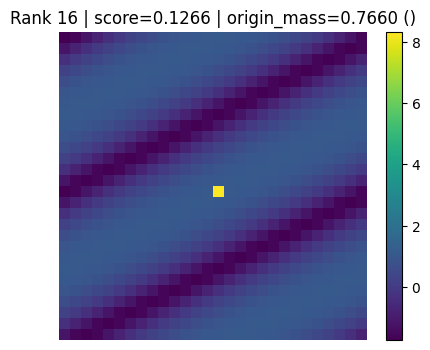


Rank 17
score        : 0.113103
origin_mass  : 0.719688
gamma_star   : 0.040039
s_max_star   : 0.000653
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8, 9, 0}, 'time_grid': [300], 'sigma0': 100.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


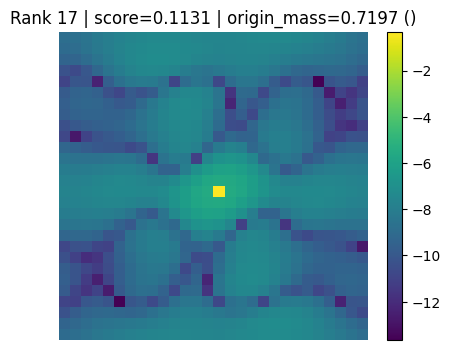


Rank 18
score        : 0.095388
origin_mass  : 0.760945
gamma_star   : 0.039062
s_max_star   : 0.000517
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {9}, 'time_grid': [300], 'sigma0': 100.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


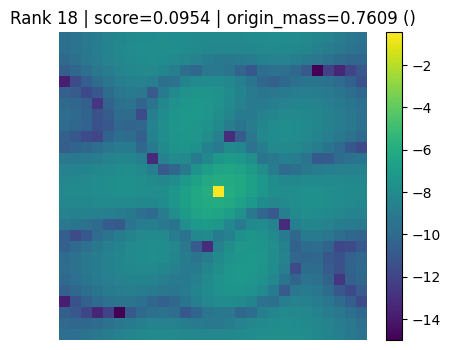


Rank 19
score        : 0.065718
origin_mass  : 0.857611
gamma_star   : 0.039062
s_max_star   : 0.000384
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [200], 'sigma0': 100.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}


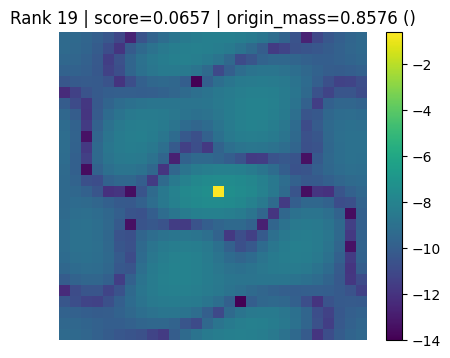


Rank 20
score        : 0.018924
origin_mass  : 0.953038
gamma_star   : 2.998047
s_max_star   : 81.569694
params       : {'intra_classes': {1, 2, 7}, 'inter_classes': {8, 9, 0}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}


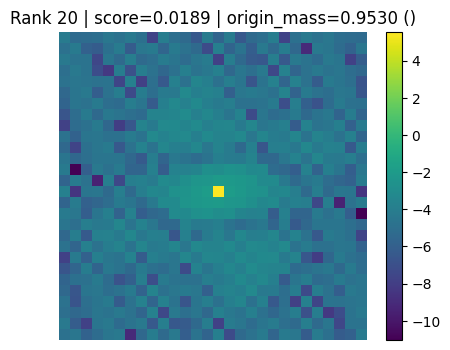


Top 1
score: 0.4808166911684965
params: {'intra_classes': {1, 2, 7}, 'inter_classes': {8, 9, 0}, 'time_grid': [398], 'sigma0': 10.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}
kernel shape: (28, 28)

Top 2
score: 0.47495458362498993
params: {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [398], 'sigma0': 10.0, 'eps_s': 1e-05, 'delta_close': 50.0, 'beta_start': 1e-06, 'bisection_iters': 10}
kernel shape: (28, 28)

Top 3
score: 0.46979880929201884
params: {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 0.5, 'beta_start': 1e-06, 'bisection_iters': 10}
kernel shape: (28, 28)

Top 4
score: 0.469660968744819
params: {'intra_classes': {1, 2, 7}, 'inter_classes': {8}, 'time_grid': [398], 'sigma0': 1.0, 'eps_s': 1e-05, 'delta_close': 5.0, 'beta_start': 1e-06, 'bisection_iters': 10}
kernel shape: (28, 28)

Top 5
score: 0.46823725576464825
params: {'intra_classes': {1, 2, 7}

In [15]:
search_space = {
    "intra_classes": [1,7,{1,2,7}],
    "inter_classes": [{8}, {9}, {8,9,0}],
    "time_grid": [[200], [300], [398]],
    "sigma0": [1.0,10.0,100.0],
    "eps_s": [1e-5],
    "delta_close": [0.5, 5.0, 50.0],
    "beta_start": [1e-6],
    "bisection_iters": [10],
}

search_out = search_mnist_preconditioner_hyperparams(
    search_space=search_space,
    top_k=10,
    T_steps=400,
    beta_end=0.02,
    solver="SCS",                 
    outer_print_progress=True,
    inner_bisection_logs=False,
    visualize_top_k=True,
    build_dense_M_for_top=False,  # set True to build the M for top 
)

top3 = search_out["top_results"]

# Access  top hyperparameter pairs
for i, r in enumerate(top3, start=1):
    print(f"\nTop {i}")
    print("score:", r["score"])
    print("params:", r["params"])
    print("kernel shape:", r["kernel_hw"].shape)   # (28, 28)

In [30]:

M = torch.rand(784,784, dtype=torch.float32).cpu()
print(type(M))

torch.save(M, "M_784.pt")

print("\nSaved M as M_784.pt")

<class 'torch.Tensor'>

Saved M as M_784.pt


In [ ]:
'''
score = sum[prob_mass(u,v) * d_circ((u,v), (0,0))] / normalize by max distance

prob_mass(u,v) = m(u,v) / sum(m(a,b))

d_circ((u,v), (0,0)) = sqrt ( d_H (u) + d_W ) for d_H (u) = min(u, 28-u)

score = 0 when everything at (0,0)
'''
 

2